<a href="https://colab.research.google.com/github/ssoosso/Image-Processing/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

**1**

In [ ]:
img=np.zeros((512, 512))
cv2.circle(img,(256,256),100,(255),-1) #white circle in the middle of a black background
img = img.astype(float)

In [ ]:
rows,cols = img.shape
crow,ccol =rows//2,cols// 2

In [ ]:
dft=np.fft.fftshift(np.fft.fft2(img))

In [ ]:
y,x=np.ogrid[:rows,:cols]
dist=np.sqrt((x-ccol)**2+(y-crow)**2)
d0=30

**2**Butterworth, and Gaussian low pass filters

In [ ]:
ideal_mask=np.zeros((rows,cols))
ideal_mask[dist<=d0]=1

In [ ]:
butter_mask=1/(1+(dist/d0)**(2*2))

In [ ]:
gauss_mask=np.exp(-(dist**2)/(2*(d0**2)))

**3**high pass filter and create a sharpened image

In [ ]:
hp_mask=1-gauss_mask
sharpened_dft=dft*(1+ hp_mask)

**4**Create periodic noise and remove it using a notch filter.

In [ ]:
noise=20*np.sin(x/ 5.0)
noisy_img=img+noise
dft_noisy=np.fft.fftshift(np.fft.fft2(noisy_img))

In [ ]:
notch_mask=np.ones((rows, cols))
#coordinates for noise spikes
notch_mask[crow-2:crow+3,ccol-18:ccol-14]= 0
notch_mask[crow-2:crow+3,ccol+14:ccol+18]= 0

**5**Write a short comparison referencing:
• frequency interpretation
• filter shape and parameters
• ringing and blur trade off

In [ ]:
res_ideal=np.abs(np.fft.ifft2(np.fft.ifftshift(dft*ideal_mask)))
res_butter=np.abs(np.fft.ifft2(np.fft.ifftshift(dft*butter_mask)))
res_gauss=np.abs(np.fft.ifft2(np.fft.ifftshift(dft*gauss_mask)))
res_sharp=np.abs(np.fft.ifft2(np.fft.ifftshift(sharpened_dft)))
res_notch=np.abs(np.fft.ifft2(np.fft.ifftshift(dft_noisy*notch_mask)))

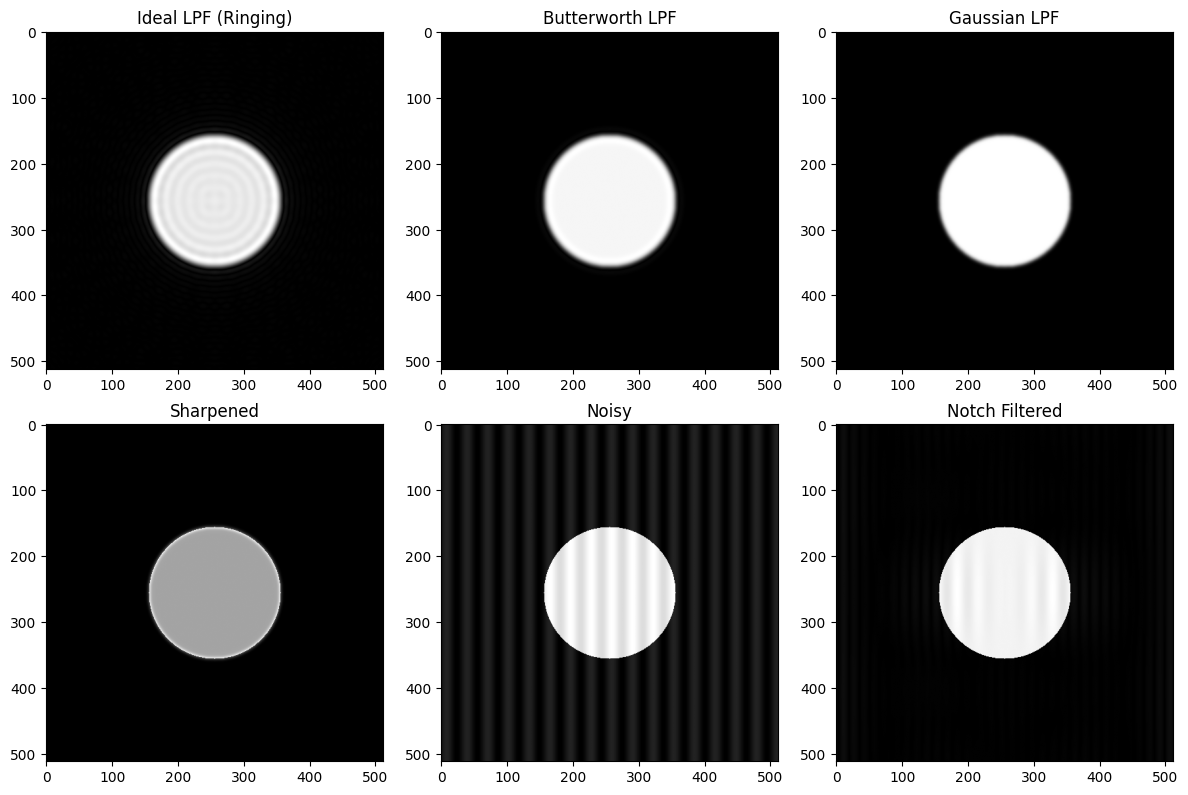

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(231), plt.imshow(res_ideal, cmap='gray'), plt.title('Ideal LPF (Ringing)')
plt.subplot(232), plt.imshow(res_butter, cmap='gray'), plt.title('Butterworth LPF')
plt.subplot(233), plt.imshow(res_gauss, cmap='gray'), plt.title('Gaussian LPF')
plt.subplot(234), plt.imshow(res_sharp, cmap='gray'), plt.title('Sharpened')
plt.subplot(235), plt.imshow(noisy_img, cmap='gray'), plt.title('Noisy')
plt.subplot(236), plt.imshow(res_notch, cmap='gray'), plt.title('Notch Filtered')
plt.tight_layout()
plt.show()

Frequency Interpretation: low pass filters keep the low frequency core (the center of the DFT) and block the high frequency edges,highpass does the opposite, capturing transitions and edges
Filter shape and parameters: ideal, A hard disk shape
Butterworth: a weighted bell shape, the order n controls how steep the transition is
Gaussian: A smooth, continuous bell curve, D0
is the standard deviation
Ringing and blur trade off: the ideal filter has the sharpest frequency selection but causes the most ringing, the gaussian filter has zero ringing but produces a softer and more natural blur

Reflction questions
1.Why is frequency filtering better for periodic noise?
Bc periodic noise shows up as bright dots in the frequency spectrum ,its much easier to just erase those specific dots than to try and fix thousands of messy pixels in the original image.

2.Why does a sharp cutoff cause ringing?
When you cut frequencies perfectly straight , the math forces the image to create ripples around edges